# Non-Local Means Denoising

## 1. Introduction et définition du problème inverse

Dans ce notebook, nous nous intéressons au problème du débruitage d'image. L'objectif est de retrouver une image propre $u$ à partir d'une observation bruitée $v$.

Le modèle de dégradation considéré est le suivant :

$$ v(p) = u(p) + n(p) $$

où $p$ désigne un pixel de l'image, et $n(p)$ est un bruit additif.

Le papier [Non-Local Means Denoising](https://www.ipol.im/pub/art/2011/bcm_nlm/article.pdf) s'attaque spécifiquement aux perturbations dues au processus de comptage de photons et aux corrections électroniques, souvent modélisées par un bruit blanc Gaussien.

Nous allons utiliser la librairie `deepinverse` pour simuler ce problème inverse.

In [ ]:
import deepinv as dinv
import matplotlib.pyplot as plt
import polars as pl
import torch
from skimage import data
from skimage.restoration import denoise_nl_means
from skimage.transform import resize
from skimage.util import img_as_float

# Configuration pour l'affichage
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["image.cmap"] = "gray"

### Chargement de l'image et modélisation du bruit

Nous utilisons une image test classique (l'astronaute) et nous la convertissons en niveaux de gris pour simplifier la première approche, bien que l'algorithme fonctionne aussi en couleur.

In [7]:
# 1. Chargement de l'image propre
# On utilise une image de skimage, convertie en float [0, 1]
img = img_as_float(data.astronaut())
img = resize(
    img, (256, 256), anti_aliasing=True
)  # Redimensionnement pour accélérer les tests

# Conversion en tenseur DeepInverse (C, H, W)
# DeepInverse attend un tenseur Torch
x_true = torch.tensor(img).permute(2, 0, 1).float().unsqueeze(0)  # (N, C, H, W)

# 2. Définition de l'opérateur Forward
# Le papier teste plusieurs niveaux de bruit sigma.
# Commençons par sigma = 15 (sur une échelle 0-255) -> 15/255 en float.
sigma_val_init = 15.0
sigma_init = sigma_val_init / 255.0

# Denoising Physics : y = x + noise
noise_model = dinv.physics.GaussianNoise(sigma=sigma_init)
physics = dinv.physics.Denoising(noise_model=noise_model)

# 3. Génération de l'image bruitée
y = physics(x_true)

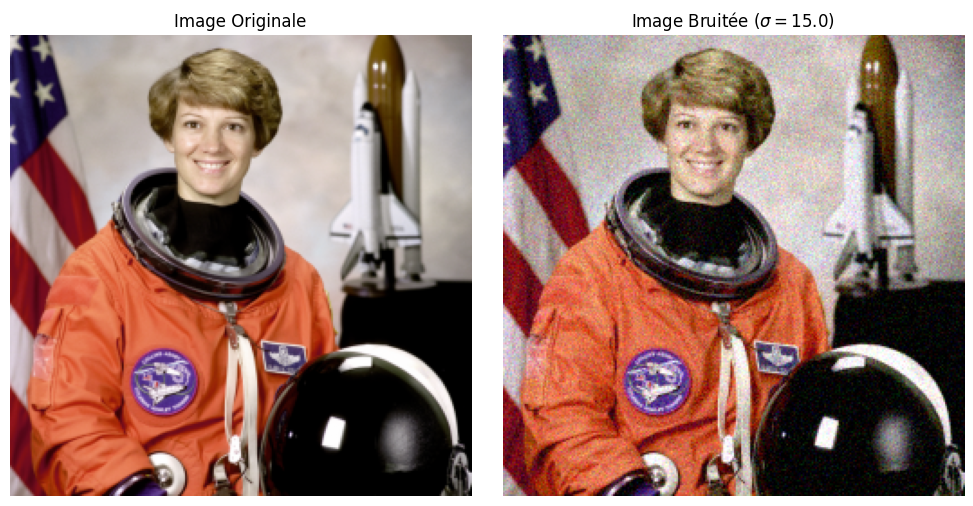

In [8]:
# Visualisation des images originale et bruitée
imgs = [
    x_true.squeeze().permute(1, 2, 0).numpy(),
    y.squeeze().permute(1, 2, 0).clamp(0, 1).numpy(),
]
titles = ["Image Originale", f"Image Bruitée ($\sigma={sigma_val_init}$)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img_data, title in zip(axes, imgs, titles):
    ax.imshow(img_data, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

## 2. Description de la méthode (Non-Local Means)

### Principe fondamental
Contrairement aux méthodes locales qui moyennent les pixels voisins (spatialement proches), l'algorithme Non-Local Means (NL-Means) repose sur la **redondance** naturelle des images. L'idée est de remplacer la valeur d'un pixel par une moyenne pondérée de tous les pixels de l'image (ou d'une grande fenêtre de recherche) qui possèdent un voisinage (patch) similaire.

Ainsi, les pixels "similaires" n'ont pas besoin d'être voisins. Ils peuvent se trouver n'importe où dans la zone de recherche.

### Formulation mathématique

La valeur débruitée $NL(u)(p)$ au pixel $p$ est donnée par :

$$ NL(u)(p) = \frac{1}{C(p)} \int_{\Omega} e^{-\frac{d(B(p), B(q))^2}{h^2}} u(q) dq $$

où :
* $d(B(p), B(q))$ est la distance Euclidienne (souvent pondérée par une Gaussienne) entre le patch centré en $p$ et le patch centré en $q$.
* $h$ est le paramètre de filtrage qui contrôle la décroissance des poids.
* $C(p)$ est une constante de normalisation.

### Implémentation : Pixelwise vs Patchwise
* **Pixelwise :** On restaure pixel par pixel en moyennant les valeurs centrales des patchs similaires.
* **Patchwise :** On restaure un patch entier à la fois. Comme les patchs se chevauchent, on obtient plusieurs estimations pour chaque pixel, qu'on moyenne ensuite. Cette méthode, implémentée par défaut dans beaucoup de librairies modernes, permet de réduire davantage la variance du bruit et d'obtenir des résultats plus "élégants" (moins d'artefacts).

## 3. Positionnement et nouveauté (état de l'art)

À sa publication (2005/2011), cette méthode marquait une rupture avec les filtres classiques :

* **Limites des méthodes locales (Moyenne, Gaussien) :** Elles supposent que les pixels voisins ont la même couleur. Cela fonctionne sur les zones plates mais floute les bords et détruit les textures fines.
* **L'innovation "Non-Locale" :** En cherchant les motifs similaires à distance, NL-Means préserve exceptionnellement bien les **textures répétitives** et les **bords nets**, car il moyenne des pixels qui appartiennent à la même structure logique, même s'ils sont éloignés spatialement.

## 4. Implémentation de l'algorithme

Nous allons maintenant implémenter le "wrapper" autour de l'algorithme NL-Means, en respectant scrupuleusement les paramètres recommandés par le papier (Tableau 1 - Couleur).

### Paramètres du papier (Table 1 - Color)
| Sigma | Patch Size (Comp. Patch) | Search Window (Res. Block) | h |
| :--- | :--- | :--- | :--- |
| $0 < \sigma \le 25$ | $3 \times 3$ | $21 \times 21$ | $0.55\sigma$ |
| $25 < \sigma \le 55$ | $5 \times 5$ | $35 \times 35$ | $0.40\sigma$ |
| $55 < \sigma \le 100$ | $7 \times 7$ | $35 \times 35$ | $0.35\sigma$ |

NL-Means Params pour sigma=15.0: Patch=3x3, Window=21x21, h=0.0324
Dimensions après débruitage : torch.Size([1, 3, 256, 256])


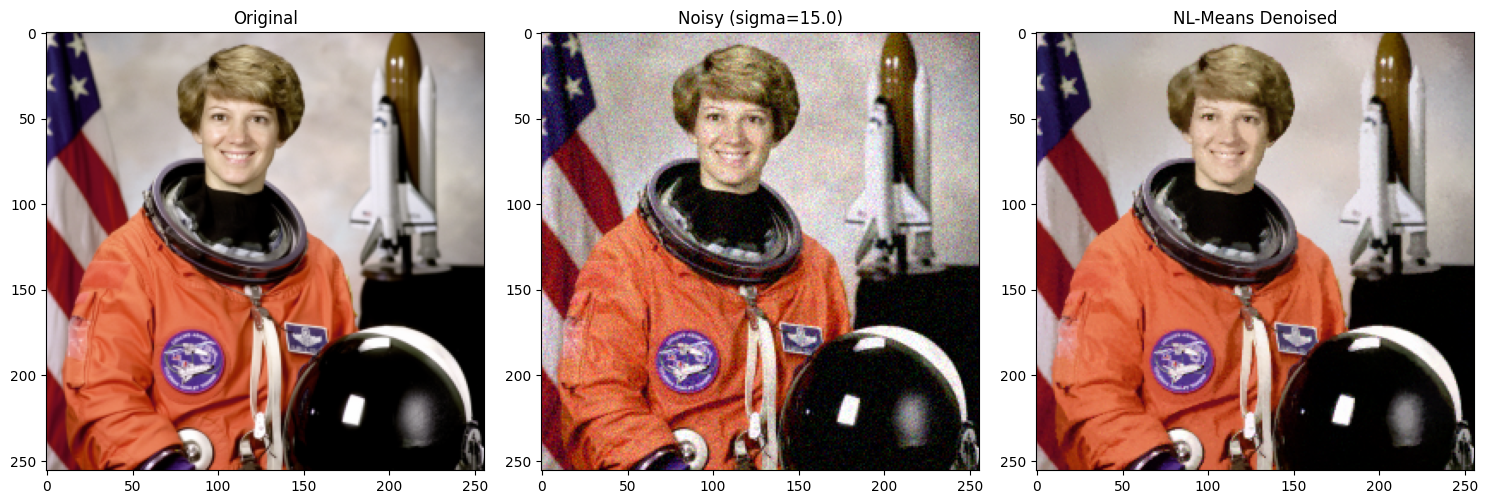

In [9]:
def get_nlm_params(sigma_val):
    """
    Retourne les paramètres (patch_size, patch_distance, h) selon le Tableau 1 (Couleur) du papier.
    sigma_val est supposé être sur l'échelle [0, 255].
    """
    if 0 < sigma_val <= 25:
        patch_size = 3
        # Fenêtre 21x21 => rayon = 10
        patch_distance = 10
        h_val = 0.55 * sigma_val
    elif 25 < sigma_val <= 55:
        patch_size = 5
        # Fenêtre 35x35 => rayon = 17
        patch_distance = 17
        h_val = 0.40 * sigma_val
    elif 55 < sigma_val <= 100:
        patch_size = 7
        patch_distance = 17
        h_val = 0.35 * sigma_val
    else:
        # Fallback pour sigma très grand ou 0
        patch_size = 11
        patch_distance = 17
        h_val = 0.30 * sigma_val

    return patch_size, patch_distance, h_val


def nlm_denoising(noisy_tensor, sigma_val):
    """
    Applique NL-Means sur un tenseur DeepInverse (N, C, H, W).
    Convertit en numpy (H, W, C), traite, et reconvertit en tenseur.
    """
    # 1. Préparation des données
    # On suppose batch size = 1 pour simplifier
    device = noisy_tensor.device
    noisy_np = noisy_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

    # 2. Récupération des paramètres
    patch_size, patch_distance, h_val = get_nlm_params(sigma_val)

    # Le paramètre h de skimage s'attend à être relatif à l'échelle des valeurs de l'image.
    # Notre image est en float [0, 1].
    # Notre h_val est calculé sur l'échelle [0, 255] (formules du papier).
    # Il faut donc normaliser h_val par 255.
    h_float = h_val / 255.0

    # sigma aussi doit être fourni à skimage si on veut l'estimation de patch
    sigma_float = sigma_val / 255.0

    print(
        f"NL-Means Params pour sigma={sigma_val}: Patch={patch_size}x{patch_size}, "
        f"Window={2 * patch_distance + 1}x{2 * patch_distance + 1}, h={h_float:.4f}"
    )

    # 3. Application de NL-Means
    # channel_axis=-1 car l'image est (H, W, C)
    denoised_np = denoise_nl_means(
        image=noisy_np,
        patch_size=patch_size,
        patch_distance=patch_distance,
        h=h_float,
        fast_mode=True,  # Approximation pour la vitesse, mettre False pour exactitude
        sigma=sigma_float,  # Aide à l'estimation des distances
        preserve_range=False,
        channel_axis=-1,
    )

    # 4. Reconversion en tenseur
    denoised_tensor = (
        torch.from_numpy(denoised_np).float().permute(2, 0, 1).unsqueeze(0).to(device)
    )

    # Clip des valeurs pour rester dans l'intervalle valide [0, 1]
    denoised_tensor = torch.clamp(denoised_tensor, 0.0, 1.0)

    return denoised_tensor


# Test rapide de la fonction
x_est = nlm_denoising(y, sigma_val_init)
print("Dimensions après débruitage :", x_est.shape)

# Visualisation rapide du résultat
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(x_true.squeeze().permute(1, 2, 0), vmin=0, vmax=1)
plt.title("Original")
plt.subplot(1, 3, 2)
plt.imshow(y.squeeze().permute(1, 2, 0).clamp(0, 1), vmin=0, vmax=1)
plt.title(f"Noisy (sigma={sigma_val_init})")
plt.subplot(1, 3, 3)
plt.imshow(x_est.squeeze().permute(1, 2, 0), vmin=0, vmax=1)
plt.title("NL-Means Denoised")
plt.tight_layout()

## 5. Résultats et analyse

Nous allons maintenant évaluer la méthode sur plusieurs niveaux de bruit et comparer les métriques (PSNR, SSIM).


--- Traitement pour Sigma = 15 ---
NL-Means Params pour sigma=15: Patch=3x3, Window=21x21, h=0.0324

--- Traitement pour Sigma = 30 ---
NL-Means Params pour sigma=30: Patch=5x5, Window=35x35, h=0.0471

--- Traitement pour Sigma = 45 ---
NL-Means Params pour sigma=45: Patch=5x5, Window=35x35, h=0.0706

=== Tableau des résultats ===


Sigma,PSNR Noisy (dB),PSNR Denoised (dB),SSIM
i64,f64,f64,f64
15,24.6,31.18,0.907
30,18.61,27.74,0.852
45,15.09,25.66,0.772


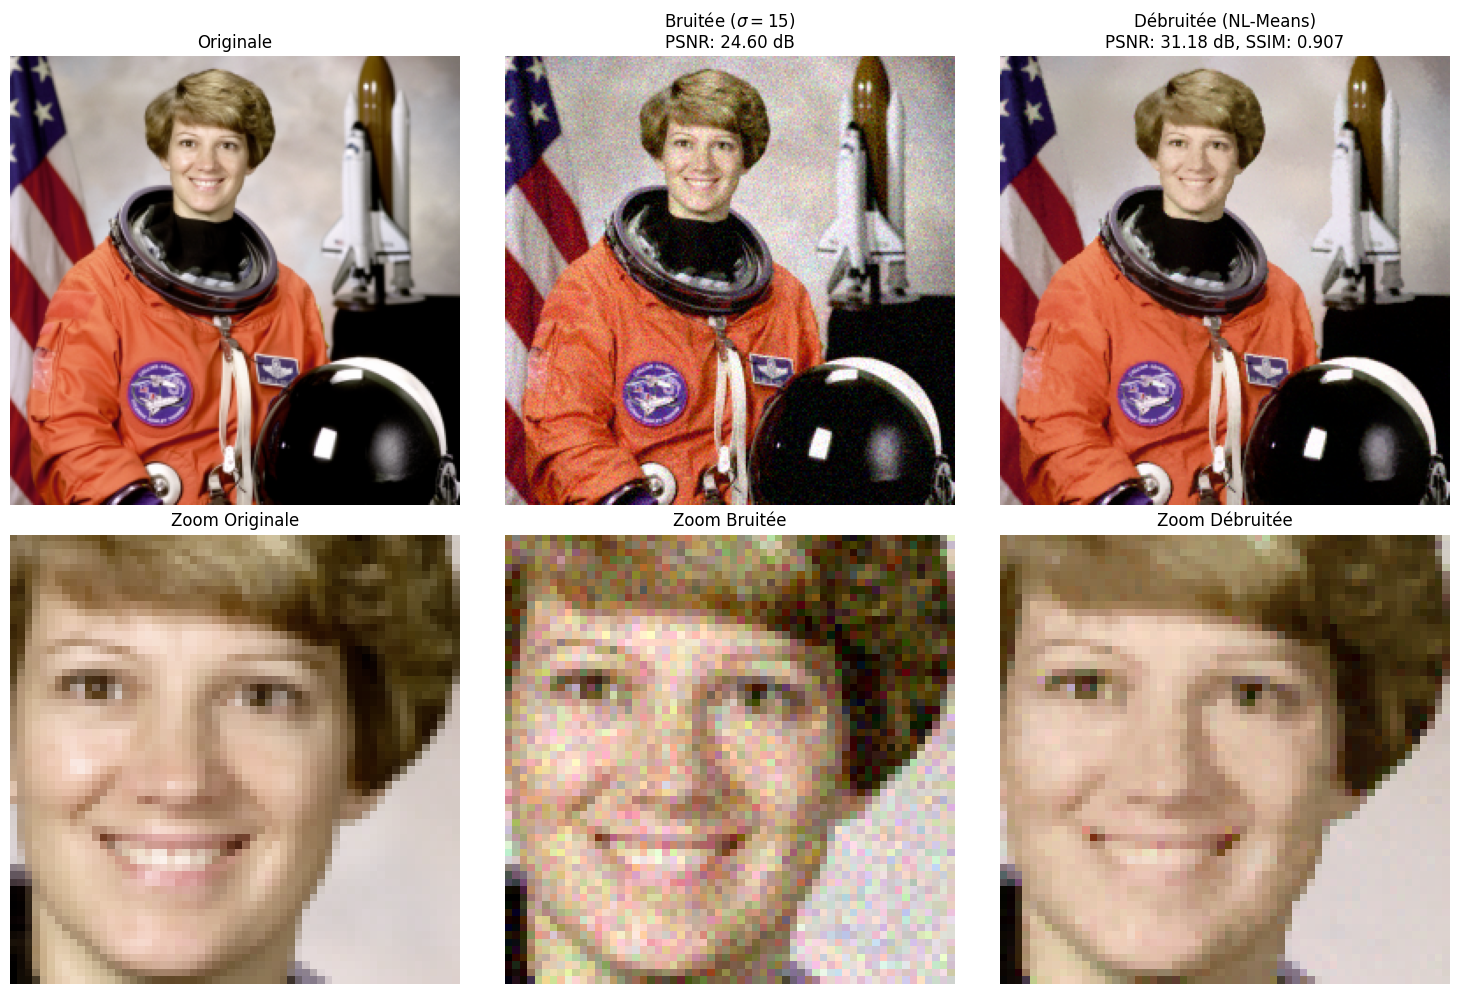

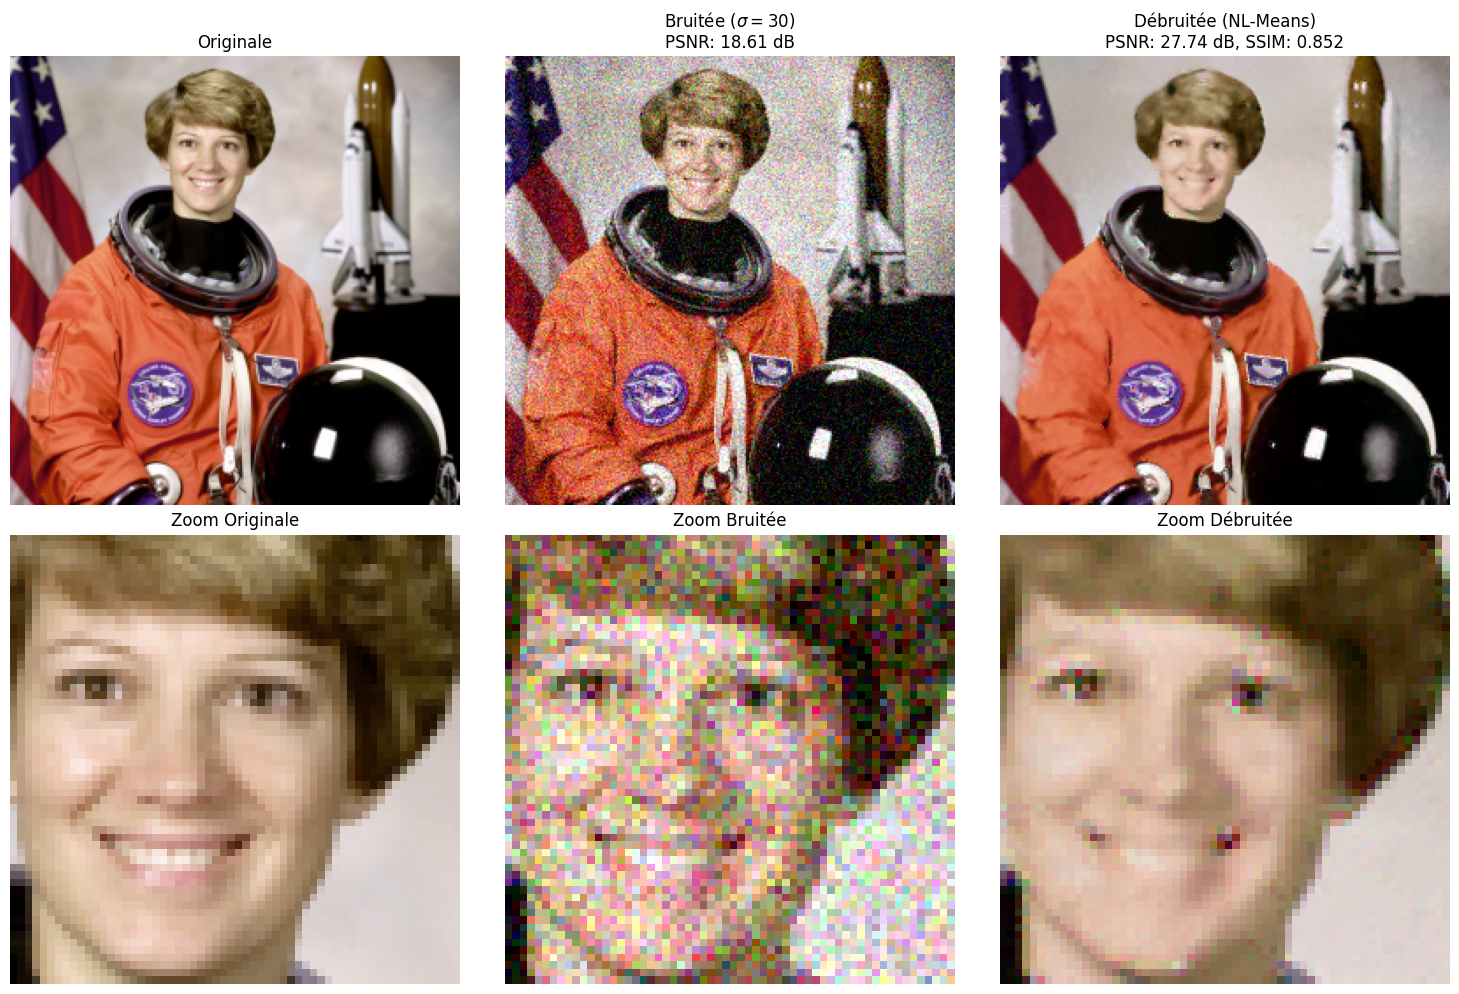

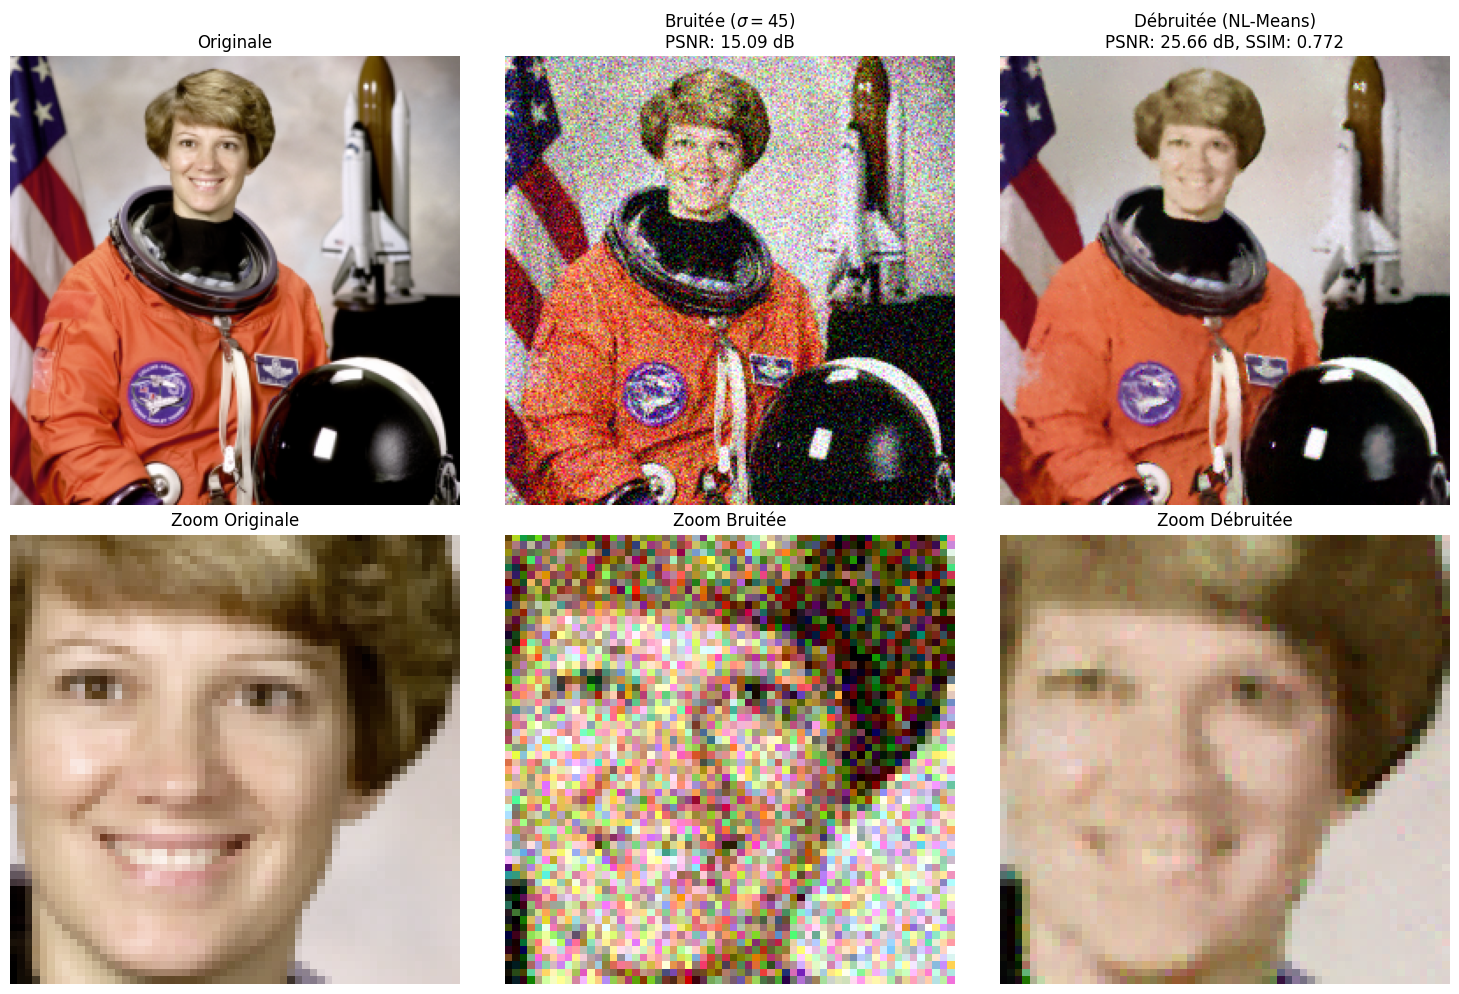

In [10]:
# Définition des niveaux de bruit à tester
sigma_levels = [15, 30, 45]
results = []
ssim_metric = dinv.metric.SSIM()

# Définition de la zone de zoom
zoom_slice = (slice(30, 90), slice(90, 150))

for s_val in sigma_levels:
    print(f"\n--- Traitement pour Sigma = {s_val} ---")
    s_float = s_val / 255.0

    # 1. Génération du bruit
    # On met à jour le modèle de bruit de l'opérateur physique
    physics.noise_model = dinv.physics.GaussianNoise(sigma=s_float)
    y_s = physics(x_true)

    # 2. Débruitage
    x_est_s = nlm_denoising(y_s, s_val)

    # 3. Calcul des métriques
    # PSNR
    psnr = dinv.metric.cal_psnr(x_true, x_est_s)
    # SSIM
    ssim = ssim_metric(x_true, x_est_s)

    # Calcul PSNR image bruitée pour comparaison
    psnr_noisy = dinv.metric.cal_psnr(x_true, y_s)

    # Extraction des valeurs scalaires
    psnr_val = psnr.item()
    ssim_val = ssim.item()
    psnr_noisy_val = psnr_noisy.item()

    results.append(
        {
            "Sigma": s_val,
            "PSNR Noisy (dB)": psnr_noisy_val,
            "PSNR Denoised (dB)": psnr_val,
            "SSIM": ssim_val,
        }
    )

    # Sauvegarde d'une figure pour chaque sigma avec Zoom
    plt.figure(figsize=(15, 10))

    # --- Ligne 1 : Images Complètes ---
    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(x_true.squeeze().permute(1, 2, 0), vmin=0, vmax=1)
    plt.title("Originale")
    plt.axis("off")

    # Noisy
    plt.subplot(2, 3, 2)
    plt.imshow(y_s.squeeze().permute(1, 2, 0).clamp(0, 1), vmin=0, vmax=1)
    plt.title(f"Bruitée ($\sigma={s_val}$)\nPSNR: {psnr_noisy_val:.2f} dB")
    plt.axis("off")

    # Denoised
    plt.subplot(2, 3, 3)
    plt.imshow(x_est_s.squeeze().permute(1, 2, 0), vmin=0, vmax=1)
    plt.title(f"Débruitée (NL-Means)\nPSNR: {psnr_val:.2f} dB, SSIM: {ssim_val:.3f}")
    plt.axis("off")

    # --- Ligne 2 : Zooms ---
    # Zoom Original
    plt.subplot(2, 3, 4)
    plt.imshow(x_true.squeeze().permute(1, 2, 0).numpy()[zoom_slice], vmin=0, vmax=1)
    plt.title("Zoom Originale")
    plt.axis("off")

    # Zoom Noisy
    plt.subplot(2, 3, 5)
    plt.imshow(
        y_s.squeeze().permute(1, 2, 0).clamp(0, 1).numpy()[zoom_slice], vmin=0, vmax=1
    )
    plt.title("Zoom Bruitée")
    plt.axis("off")

    # Zoom Denoised
    plt.subplot(2, 3, 6)
    plt.imshow(x_est_s.squeeze().permute(1, 2, 0).numpy()[zoom_slice], vmin=0, vmax=1)
    plt.title("Zoom Débruitée")
    plt.axis("off")

    plt.tight_layout()

print("\n=== Tableau des résultats ===")
pl.DataFrame(results).select(
    pl.col("Sigma"),
    pl.col("PSNR Noisy (dB)").round(2),
    pl.col("PSNR Denoised (dB)").round(2),
    pl.col("SSIM").round(3),
)

### Discussion

* **Zones plates vs Textures :** On observe que NL-Means est très efficace pour lisser les zones uniformes (ciel, fond) sans laisser le "grain" typique des filtres locaux simples.
* **Préservation des détails :** Grâce à la recherche non-locale, les détails répétitifs ou structurés sont mieux conservés qu'avec un flou Gaussien, bien que pour des niveaux de bruit élevés ($\sigma=45$), un certain lissage des textures fines reste inévitable.
* **Paramètre $h$ :** L'adaptation du paramètre $h$ en fonction de $\sigma$ (comme proposé dans le papier) est cruciale. Un $h$ trop faible laisserait du bruit résiduel, un $h$ trop fort effacerait les détails.